In [1]:
#importing libraries
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats as stats


In [2]:
#checking for one level up folder file
import os
os.listdir("..")

['data', 'notebooks', 'README.md', 'requirements.txt', 'visuals']

## 01. Data Loading

In [3]:
#data loading 
df = pd.read_csv("../data/retail_sales_dataset.csv")  #go to one step backward by ../ and then step into data file 
df_original = df.copy()


## 02. Initial Data Inspection

In [4]:
# initial data view
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [5]:
#checking row and column numbers
df.shape

(1000, 9)

In [6]:
#checking all column names
df.columns.tolist()

['Transaction ID',
 'Date',
 'Customer ID',
 'Gender',
 'Age',
 'Product Category',
 'Quantity',
 'Price per Unit',
 'Total Amount']

In [7]:
#checking both null values and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [8]:
#checking data types, problem found 1, Date must be changed to date type
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [9]:
#checking null values 
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [10]:
#checking duplicates
df.duplicated().sum()

0

In [11]:
#checking cat columns unique values
categorical_cols = ['Gender', 'Product Category']
for cols in categorical_cols:
  print("No of unique values:", df[cols].unique()) 
  print("Value Counts: ", df[cols].value_counts())
  print()


No of unique values: ['Male' 'Female']
Value Counts:  Gender
Female    510
Male      490
Name: count, dtype: int64

No of unique values: ['Beauty' 'Clothing' 'Electronics']
Value Counts:  Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64



In [12]:
#checking uniquness 
print(df['Transaction ID'].nunique())  #each transaction represent one purchase, it must be unique
print(df['Customer ID'].nunique())    # customer behaviour can't be analysed as customer id is unique, one person one purchase

1000
1000


In [13]:
df['Customer ID'].value_counts().head()

Customer ID
CUST001    1
CUST672    1
CUST659    1
CUST660    1
CUST661    1
Name: count, dtype: int64

In [14]:
#checkinng for outliers and inconsistencies in numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Transaction ID,1000.0,500.500,288.819436,1.0,250.75,500.5,750.25,1000.0
Age,1000.0,41.392,13.681430,18.0,29.00,42.0,53.00,64.0
Quantity,1000.0,2.514,1.132734,1.0,1.00,3.0,4.00,4.0
Price per Unit,1000.0,179.890,189.681356,25.0,30.00,50.0,300.00,500.0
Total Amount,1000.0,456.000,559.997632,25.0,60.00,135.0,900.00,2000.0


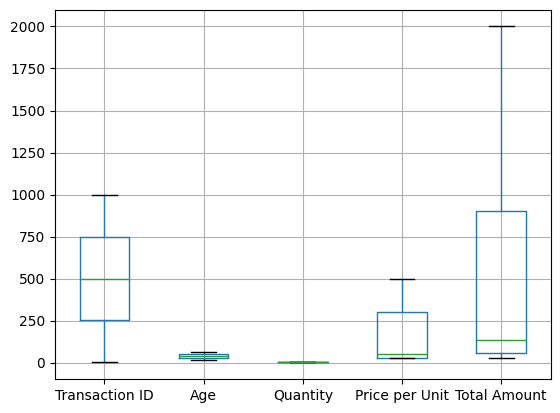

In [15]:
#quickly checking outliers in numerical cols

df.boxplot()
plt.show()

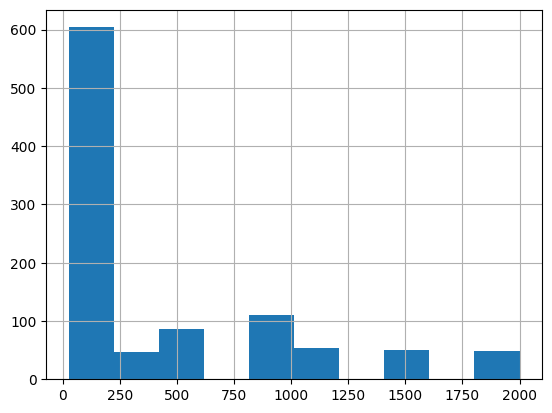

In [16]:
df['Total Amount'].hist()
plt.show()

In [17]:
#validating total amount column 
inconsistent_data = df[df['Total Amount'] != df['Price per Unit']*df['Quantity']]
len(inconsistent_data)

0

## 03. Data Cleaning

In [18]:
df['Date'] = pd.to_datetime(df['Date'])

In [19]:
df.dtypes

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

## 04. Exploratory Data Analysis

### Univariate Analysis

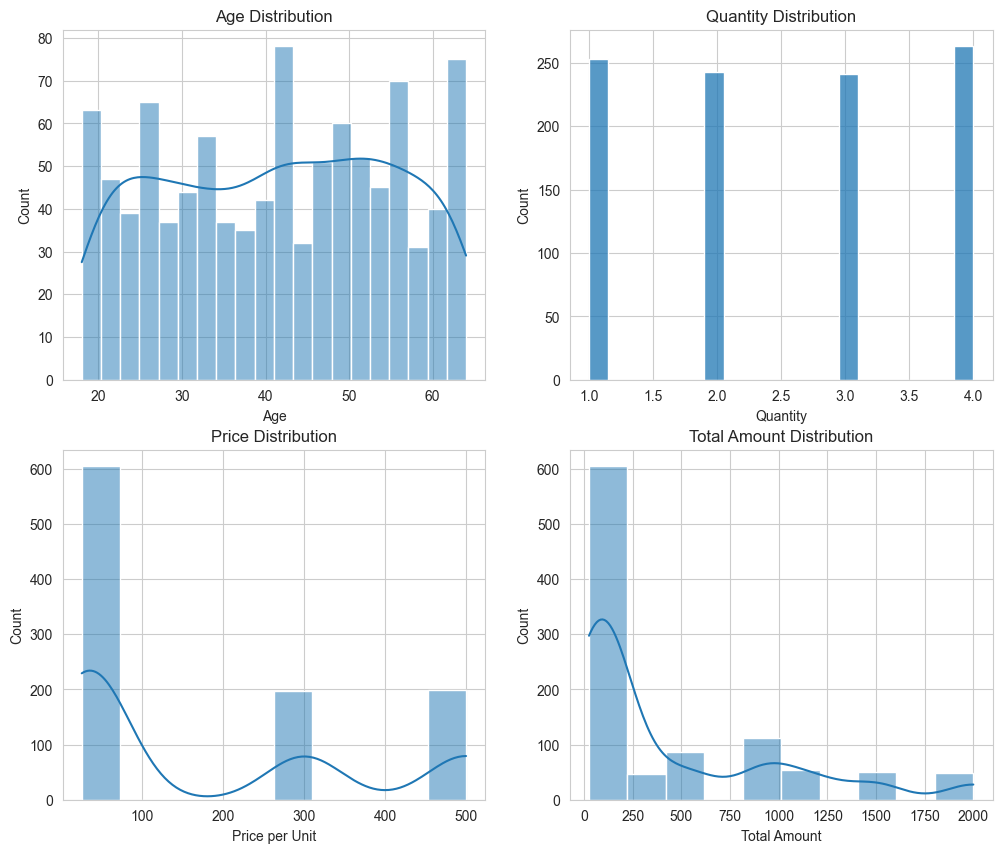

In [20]:
#plot distribution of neumerical variables
sns.set_style('whitegrid')

fig,axes = plt.subplots(2,2, figsize= (12,10))

sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0,0])
axes[0,0].set_title('Age Distribution')

sns.histplot(df['Quantity'], bins=20, kde=False, ax=axes[0,1])
axes[0,1].set_title('Quantity Distribution')

sns.histplot(df['Price per Unit'], bins=10, kde=True, ax=axes[1,0])
axes[1,0].set_title('Price Distribution')

sns.histplot(df['Total Amount'], bins=10, kde=True, ax=axes[1,1])
axes[1,1].set_title('Total Amount Distribution')

plt.show()
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

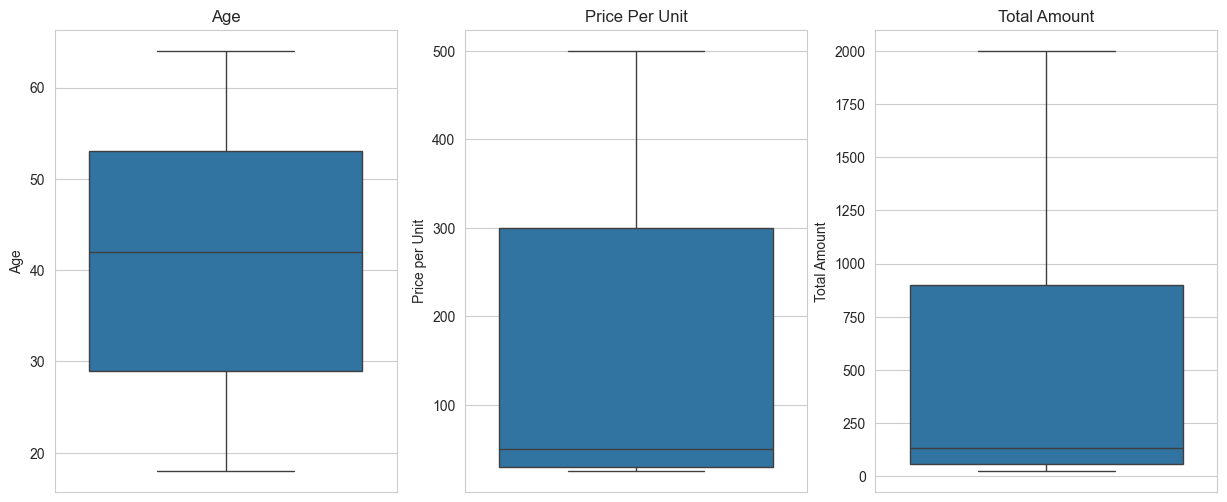

In [21]:
# check outliers 
sns.set_style('whitegrid')

fig, axes = plt.subplots(1,3, figsize=(15,6))

sns.boxplot(df['Age'], ax=axes[0])
axes[0].set_title("Age")

sns.boxplot(df['Price per Unit'], ax=axes[1])
axes[1].set_title("Price Per Unit")

sns.boxplot(df['Total Amount'], ax=axes[2])
axes[2].set_title("Total Amount")


plt.show()
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

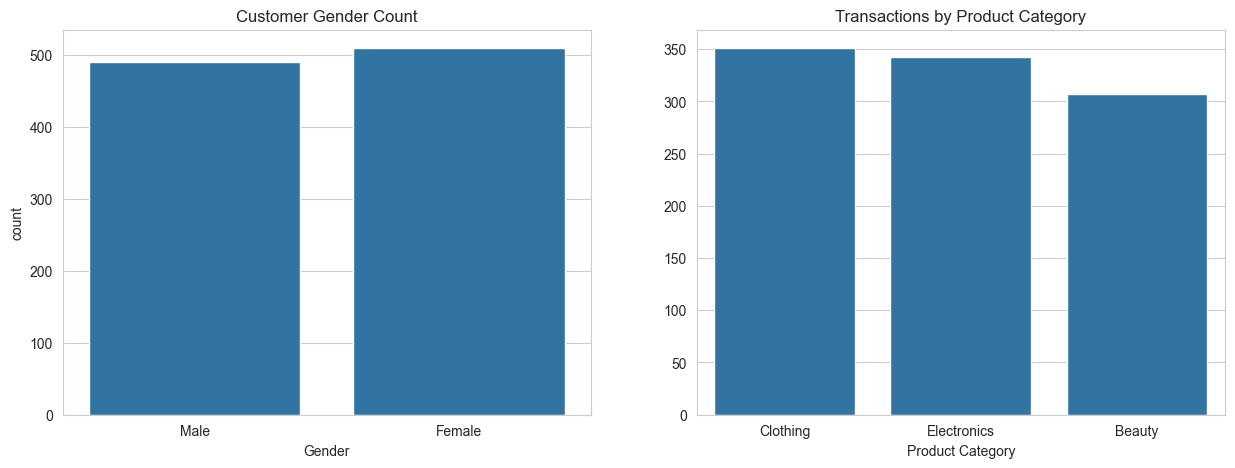

Gender
Female    510
Male      490
Name: count, dtype: int64

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


In [22]:
# plot distribution for categorical variables
fig, axes= plt.subplots(1,2, figsize=(15,5))

sns.countplot(data=df, x='Gender', ax=axes[0])
axes[0].set_title('Customer Gender Count')

category_counts = df['Product Category'].value_counts()    #countplot can also be used, but countplot doesn't apply descending order (both give same answer)
sns.barplot(x=category_counts.index, y=category_counts.values, ax=axes[1])
axes[1].set_title('Transactions by Product Category')

plt.show()
plt.tight_layout()

#transaction occured
print(df['Gender'].value_counts())
print()
print(df['Product Category'].value_counts())

### Bivariate Analysis 

In [23]:
# avg amount spending by gender
df.groupby('Gender')['Total Amount'].mean()

Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


<Figure size 640x480 with 0 Axes>

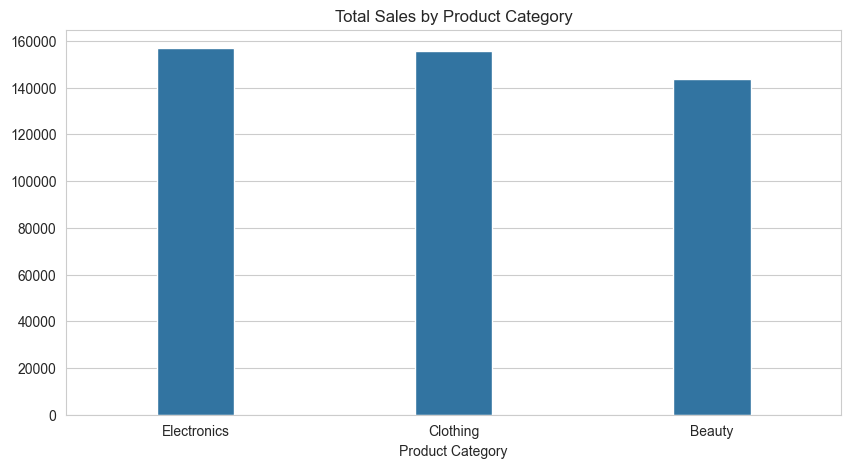

In [24]:
# amount by product category
cat_total = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
print(cat_total)

plt.figure(figsize=(10,5))
sns.barplot(x=cat_total.index, y=cat_total.values, width=0.3)
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.show()
plt.tight_layout()

In [25]:
#creating age group
bins = [0, 18, 30, 40, 50, 60, 100]
labels = ['<18', '18-30', '31-40', '41-50', '51-60', '60+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,31-40
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,18-30
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,41-50
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,31-40
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,18-30


Age Group
<18      534.047619
18-30    483.055556
31-40    497.150259
41-50    424.411765
51-60    454.931818
60+      357.258065
Name: Total Amount, dtype: float64

Age Group
<18       21
18-30    252
31-40    193
41-50    221
51-60    220
60+       93
Name: Transaction ID, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_2516\3178654532.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sales = df.groupby('Age Group')['Total Amount'].mean().sort_index()
C:\Users\HP\AppData\Local\Temp\ipykernel_2516\3178654532.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Age Group')['Transaction ID'].count())


<Figure size 640x480 with 0 Axes>

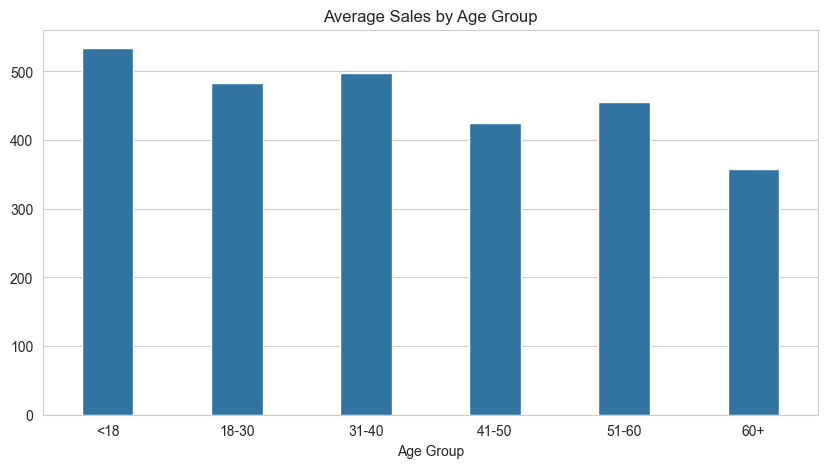

In [26]:
# avg sales by age group
age_sales = df.groupby('Age Group')['Total Amount'].mean().sort_index()
print(age_sales)

#transaction count for each age group
print()
print(df.groupby('Age Group')['Transaction ID'].count())

# plotting avg sales by age group
plt.figure(figsize=(10,5))
sns.barplot(x=age_sales.index, y= age_sales.values, width=0.4)
plt.title('Average Sales by Age Group')
plt.show()

Gender            Female  Male
Product Category              
Beauty               166   141
Clothing             174   177
Electronics          170   172


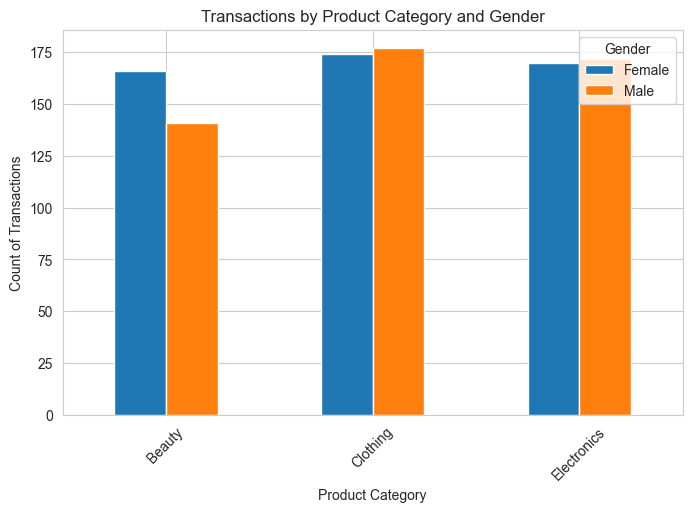

In [27]:
#count of transactions by gender and category
gender_cat = pd.crosstab(df['Product Category'], df['Gender'])
print(gender_cat)


gender_cat.plot(kind='bar', figsize=(8,5), stacked=False)
plt.title('Transactions by Product Category and Gender')    #transaction means just purchase, who purchases more
plt.ylabel('Count of Transactions')
plt.xticks(rotation=45)
plt.show()

                     Age  Quantity  Price per Unit  Total Amount
Age             1.000000 -0.023737       -0.038423     -0.060568
Quantity       -0.023737  1.000000        0.017501      0.373707
Price per Unit -0.038423  0.017501        1.000000      0.851925
Total Amount   -0.060568  0.373707        0.851925      1.000000


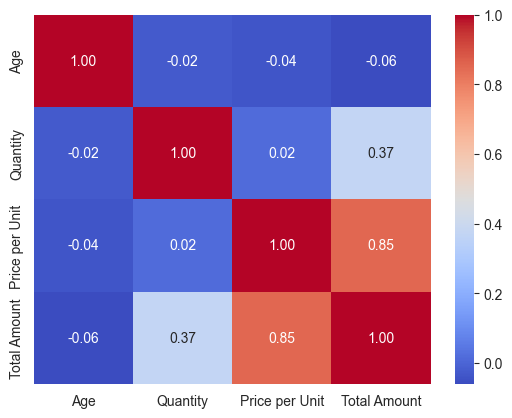

In [28]:
# checking relationship between numerical columns
num_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
corr = df[num_cols].corr()
print(corr)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

### Time-based Analysis

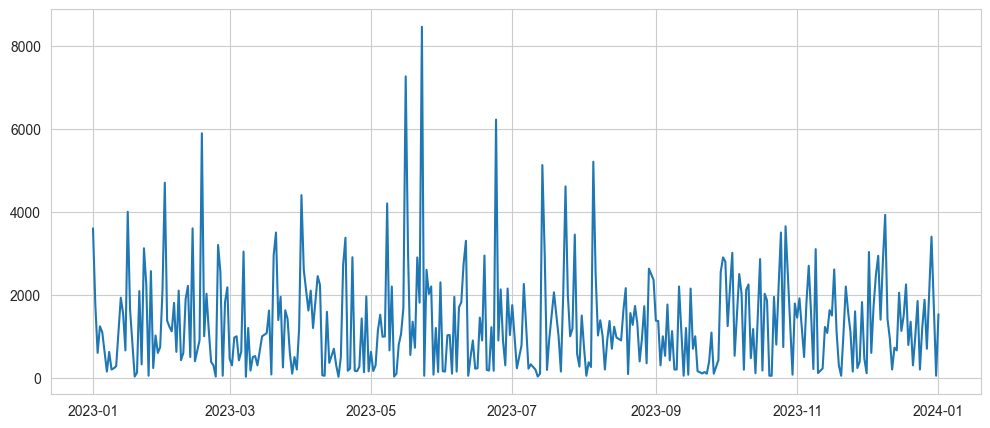

In [29]:
#aggregrating daily total sales
daily_sales = df.groupby('Date')['Total Amount'].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_sales.index, daily_sales.values)

plt.show()

      Month  Total Amount
0   2023-01         35450
1   2023-02         44060
2   2023-03         28990
3   2023-04         33870
4   2023-05         53150
5   2023-06         36715
6   2023-07         35465
7   2023-08         36960
8   2023-09         23620
9   2023-10         46580
10  2023-11         34920
11  2023-12         44690
12  2024-01          1530


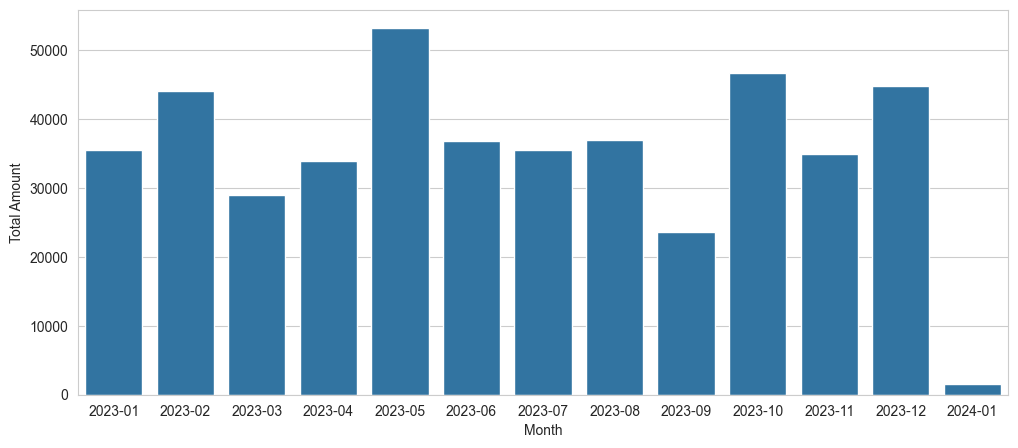

In [30]:
# extracting and aggregrating monthly sales
df['Month'] = df['Date'].dt.to_period('M')
df.head()

monthly_sales = df.groupby('Month')['Total Amount'].sum().reset_index()
print(monthly_sales)

plt.figure(figsize=(12,5))
sns.barplot(monthly_sales, x='Month', y='Total Amount')
plt.show()

    Day Name  Total Amount
0     Monday         70250
1    Tuesday         69440
2  Wednesday         58770
3   Thursday         53835
4     Friday         66290
5   Saturday         78815
6     Sunday         58600


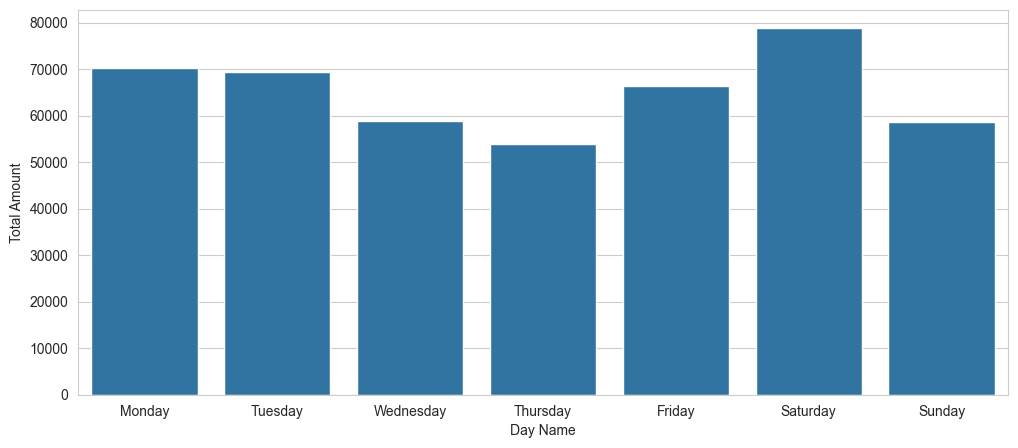

In [31]:
# extracting and aggregrating weekly sales
df['Day Name']=df['Date'].dt.day_name()

order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekly_sales = df.groupby('Day Name')['Total Amount'].sum().reindex(order).reset_index()
print(weekly_sales)


plt.figure(figsize=(12,5))
sns.barplot(weekly_sales, x='Day Name', y='Total Amount')
plt.show()

## 05. Visualization

In [32]:
# standard size and pallete creation
sns.set_style('whitegrid')
sns.set_palette("husl")

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10


### 5.1 Total Revenue by Product Category

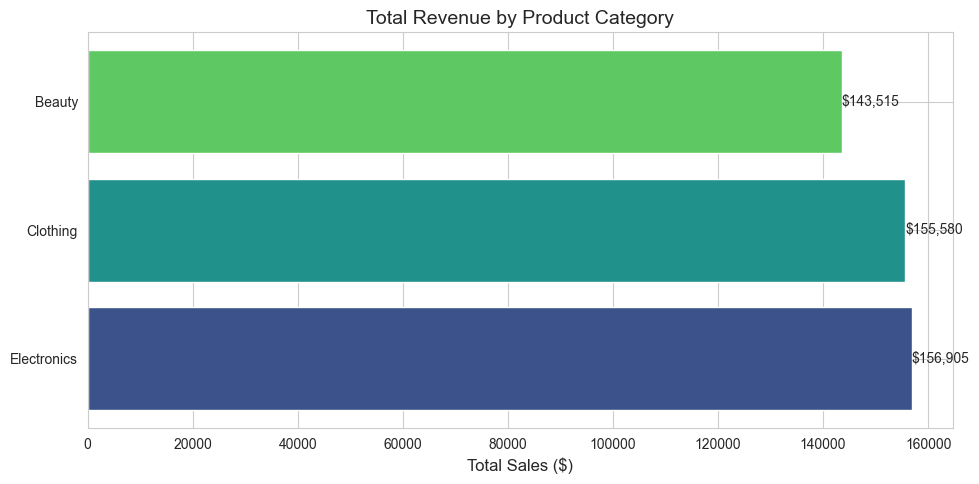

In [33]:
cat_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.barh(cat_sales.index, cat_sales.values, color=sns.color_palette("viridis", len(cat_sales)))
plt.xlabel('Total Sales ($)')
plt.title('Total Revenue by Product Category')
# Add value labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'${width:,.0f}', 
             ha='left', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../visuals/sales_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

*Insight: Electronics generate the highest revenue despite slightly fewer transactions than clothing, suggesting higher average product prices.*

### 5.2 Average Transaction Value by Age Group

C:\Users\HP\AppData\Local\Temp\ipykernel_2516\3342962818.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_spending = df.groupby('Age Group')['Total Amount'].mean()


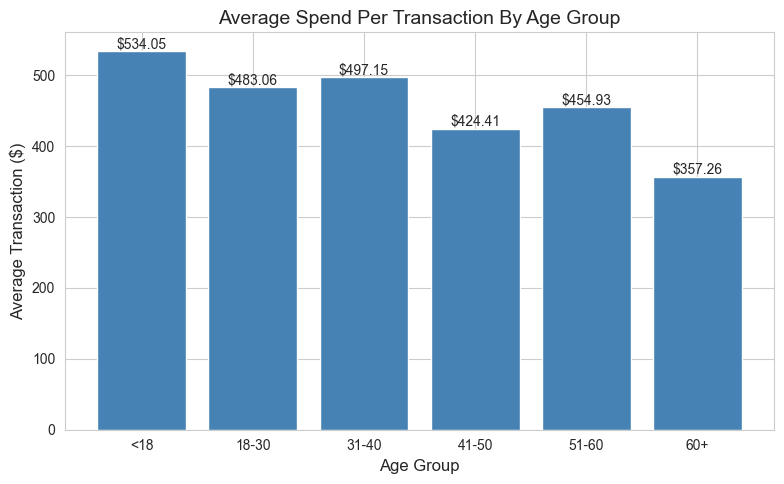

In [34]:
age_spending = df.groupby('Age Group')['Total Amount'].mean()

plt.figure(figsize=(8,5))
bars = plt.bar(age_spending.index, age_spending.values, color='steelblue')
plt.xlabel('Age Group')
plt.ylabel('Average Transaction ($)')
plt.title('Average Spend Per Transaction By Age Group')
# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'${height:.2f}', 
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('../visuals/avg_spend_by_age.png', dpi=300)
plt.show()

*Insight: The <18 age group shows the highest average transaction value ($534), but this result is based on only 21 transactions and therefore may not represent typical purchasing behavior. The majority of transactions occur within the 18–60 age groups, where average spending remains relatively consistent around $480–$500 per purchase. Customers aged 60+ show the lowest average spending levels.*

### 5.3 Monthly Sales Trend

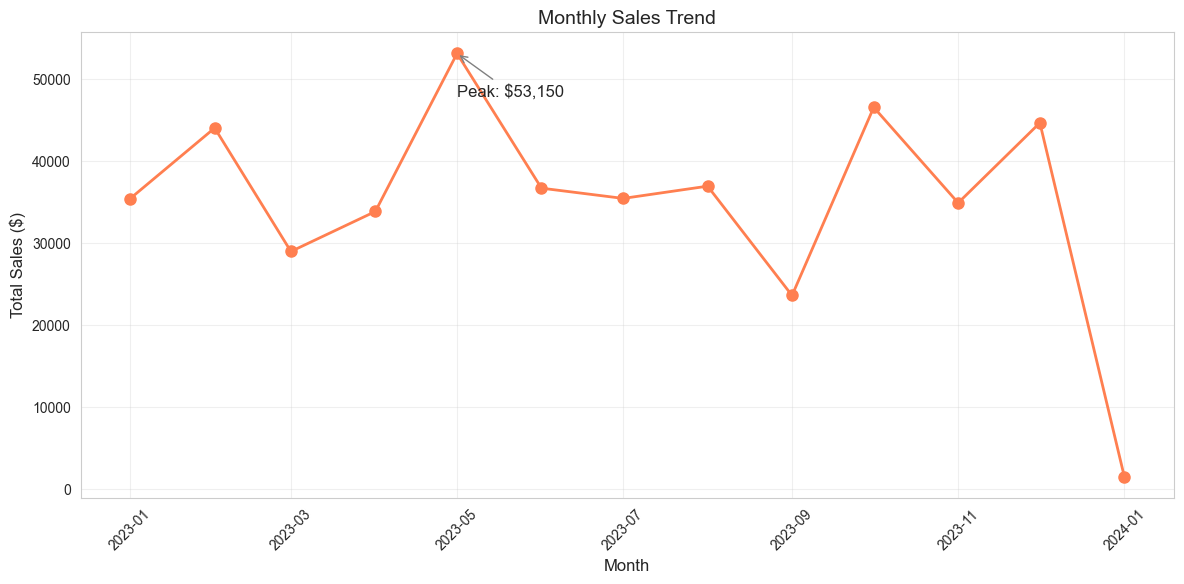

In [35]:
monthly_sales2 = df.groupby('Month')['Total Amount'].sum()

plt.figure(figsize=(12,6))

plt.plot(monthly_sales2.index.to_timestamp(),
         monthly_sales2.values,
         marker='o',
         linestyle='-',
         linewidth=2,
         markersize=8,
         color='coral')

plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)

# Annotate peak
peak_idx = monthly_sales2.idxmax()

plt.annotate(f"Peak: ${monthly_sales2.loc[peak_idx]:,.0f}",
             xy=(peak_idx.to_timestamp(), monthly_sales2.loc[peak_idx]),
             xytext=(peak_idx.to_timestamp(), monthly_sales2.loc[peak_idx]*0.9),
             arrowprops=dict(arrowstyle='->', color='gray'))

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../visuals/monthly_sales.png', dpi=300)
plt.show()

*Insight: Sales peak in May, indicating the strongest monthly performance, while January shows the lowest revenue, suggesting slower sales at the beginning of the year.*

### 5.4 Weekly Sales Trend

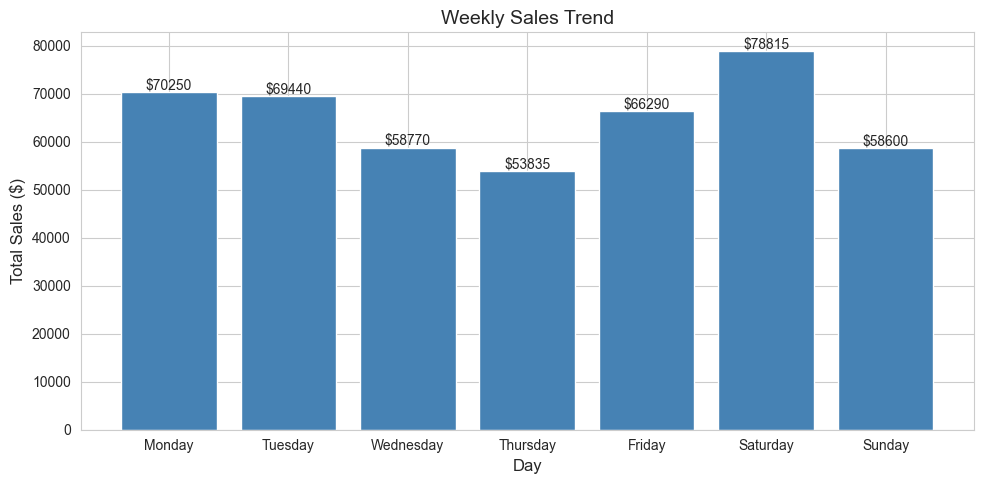

In [36]:

order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekly_sales2 = df.groupby('Day Name')['Total Amount'].sum().reindex(order).reset_index()

plt.figure(figsize=(10,5))
bars = plt.bar(weekly_sales2['Day Name'], weekly_sales2['Total Amount'], color='steelblue')
plt.xlabel('Day')
plt.ylabel('Total Sales ($)')
plt.title('Weekly Sales Trend')
# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'${height:.0f}', 
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('../visuals/weekly_sales_trend.png', dpi=300)
plt.show()

*Insight: Sales peak on Saturday, indicating increased customer activity during the weekend, while Thursday records the lowest revenue among all weekdays.*

In [37]:
# saving cleaned data 
df.to_csv('../data/retail_sales_cleaned.csv', index=False)